In [1]:
import numpy as np
from core import Simulation
import matplotlib.pyplot as plt
import pandas as pd
import eurostat
from data_scraper import *
from plotter import generate_gif
import geopandas as gpd
import imageio
import os

In [2]:
# Intrested in the year
Y = 2022
filename="connectivity_"+str(Y)+".csv"

# Fetch transportation data
df_connectivity = fetch_eu_air_traffic(year=Y, filename=filename, check=filename)

# Fetch population data
df_pop = fetch_eu_populations(year=Y)
df_pop = df_pop.set_index("Country_Code")

+ Fetching Eurostat Air Traffic Data...
Loaded succesfully!
+ Fetching Eurostat Population Data...
   -> Successfully loaded populations for 50 entities.


In [3]:
# Filter out cities with air traffic and Nan pop values
df_pop = df_pop.dropna()
valid_countries = df_pop.index.tolist()
valid_nodes = [node for node in df_connectivity.index if node in valid_countries]
df_connectivity = df_connectivity.loc[valid_nodes, valid_nodes]
df_pop = df_pop.loc[df_connectivity.index.to_list()]

In [4]:
population = df_pop.to_numpy().flatten()

# Seed 0.1% infection in the highest populated country; rest fully susceptible
S0 = population
S0[np.argmax(population)] = 0.999 * np.max(population)

I0 = np.zeros_like(population)
I0[np.argmax(population)] = 0.001 * np.max(population)

R0 = np.zeros_like(population)
init_state = np.concatenate([S0, I0, R0])

# Asymmetric commuter matrix; zero diagonal; rows sum to 0.1
C = df_connectivity.to_numpy()

sim = Simulation(
    populations=population,
    init_state=init_state,
    connection_matrix=C,
    infection_rate=0.1,       
    recovery_rate=1000000,        
    social_connectivity=0.5,
)
sim.solve_system(t_end=360) 
t, S, I, R = sim.get_results()

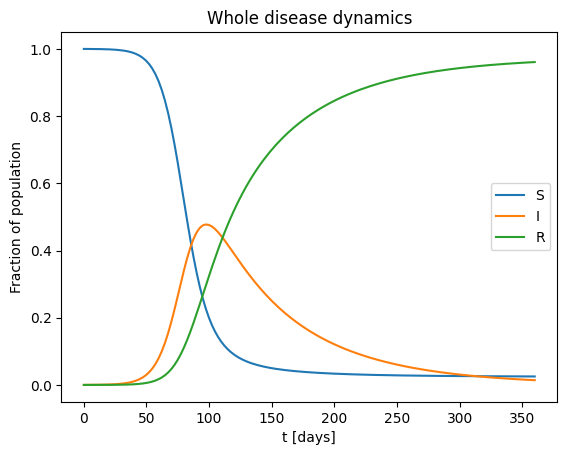

In [5]:
stats = np.stack((S.T, I.T, R.T), axis=-1)
stats_global = np.sum(stats, axis=1)
stats_global = stats_global / np.sum(stats_global, axis=1, keepdims=True)


labels = ["S", "I", "R"]

for i, l in enumerate(labels):
    plt.plot(t, stats_global[:, i], label = l)

plt.xlabel("t [days]")
plt.ylabel("Fraction of population")
plt.title('Whole disease dynamics')
plt.legend()

In [6]:
eurostat_codes = df_connectivity.index.to_list()
generate_gif(t, S, I, R, eurostat_codes)

1. Downloading map geometry from Natural Earth...
2. Setting up nodes and translating Eurostat to ISO3...
3. Generating frames...
4. Stitching into GIF...
Success! GIF saved as: sir_eu_model_2x2.gif
